# 🚀 Part 1: Introduction to Multiple Linear Regression

Welcome to the Multiple Linear Regression lab! In the previous lab, we mastered **Simple Linear Regression**, where we predicted $CO_2$ emissions using just *one* isolated feature (e.g., Engine Size). 

However, in the real world, complex phenomena are rarely governed by a single cause. A vehicle's carbon footprint is simultaneously influenced by its engine volume, cylinder count, and diverse fuel consumption rates.

---

## 🎯 Lab Objectives
By the end of this 15-minute practical lab, you will be able to:
1. Use the **`scikit-learn`** library to implement a Multiple Linear Regression architecture.
2. Select, prepare, and pass multiple independent features ($X_1, X_2, X_3$) simultaneously into a machine learning model.
3. Train, test, and mathematically evaluate a multi-variable predictor using real-world automotive data.

---

## 📐 Mathematical Transformation: Simple vs. Multiple

Instead of mapping a single straight line, Multiple Linear Regression fits a **multi-dimensional plane** through the data. The mathematical equation expands as follows:

$$\hat{y} = \theta_0 + \theta_1x_1 + \theta_2x_2 + \theta_3x_3 + ... + \theta_nx_n$$

Where:
* $\hat{y}$ = The estimated Target Output (`CO2EMISSIONS`).
* $\theta_0$ = The Intercept (constant baseline value).
* $\theta_1, \theta_2, \theta_3$ = Individual **Coefficients (Weights)** assigned to each respective feature.
* $x_1, x_2, x_3$ = The Input Features we choose (e.g., `ENGINESIZE`, `CYLINDERS`, `FUELCONSUMPTION_COMB`).

# 📦 Part 2: Importing Essential Libraries

Before we can manipulate data or train our machine learning models, we must import our core Python data science stack. These libraries work together to streamline our workflow:

* **NumPy (`np`)**: Handles high-performance multi-dimensional arrays and advanced mathematical computations.
* **Pandas (`pd`)**: Provides powerful data structures like DataFrames to load, clean, and manipulate tabular data seamlessly.
* **Matplotlib (`plt`)**: A plotting library used to create clean interactive visualizations and graphs.
* **Scikit-learn (`sklearn`)**: The primary machine learning framework containing pre-built algorithms, dataset utilities, and evaluation metrics.

---

## 🛠️ Code Implementation
Execute the following cell to import the packages and ensure they are ready for use in our session:

```python
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn import linear_model

In [2]:
!pip install numpy==2.2.0
!pip install pandas==2.2.3
!pip install scikit-learn==1.6.0
!pip install matplotlib==3.9.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 140.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 96.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 106.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 91.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 83.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 69.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 107.2 MB/s eta 0:00:00


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

## Load the data
The dataset you will use resides at the following URL. You can use the URL directly with the Pandas library to load the dataset.


In [4]:
url= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"

# 🔍 Part 4: Understanding the Data Schema

Before choosing variables for our **Multiple Linear Regression** plane, we must map and thoroughly understand the nature of each column inside our dataset. The file contains performance profiles of Canadian light-duty vehicles:

---

## 📋 Feature Breakdown

* **`MODELYEAR`**: Production year of the vehicle (e.g., 2014)
* **`MAKE`**: The manufacturer/brand (e.g., VOLVO, FORD, TOYOTA)
* **`MODEL`**: Specific vehicle model identity (e.g., S60 AWD)
* **`VEHICLECLASS`**: Classification of the vehicle size/type (e.g., COMPACT, SUV)
* **`ENGINESIZE`**: Engine displacement volume measured in Liters (e.g., 3.0)
* **`CYLINDERS`**: Number of combustion cylinders in the engine block (e.g., 6)
* **`TRANSMISSION`**: Transmission type and gear count (e.g., AS6)
* **`FUELTYPE`**: Chemical fuel designation (e.g., Z = Premium Gasoline, X = Regular Gasoline)
* **`FUELCONSUMPTION_CITY`**: Fuel consumption rate within city traffic ($L/100\text{ km}$)
* **`FUELCONSUMPTION_HWY`**: Fuel consumption rate during highway cruising ($L/100\text{ km}$)
* **`FUELCONSUMPTION_COMB`**: Weighted combined fuel efficiency metric ($L/100\text{ km}$)
* **`FUELCONSUMPTION_COMB_MPG`**: Combined fuel efficiency displayed in Miles Per Gallon ($MPG$)
* **`CO2EMISSIONS`**: **[TARGET]** The literal mass of carbon dioxide emitted per kilometer driven ($g/km$)

---

## 🎯 Our Objective
Unlike the prior simple line model, we will strategically isolate a subset of **multiple continuous features** simultaneously (such as `ENGINESIZE`, `CYLINDERS`, and `FUELCONSUMPTION_COMB`) to construct a highly accurate multi-variable equation capable of predicting `CO2EMISSIONS` for unobserved future vehicles.

# 📥 Part 5: Loading and Verifying the Dataset

We read the fuel consumption source data directly into a Pandas DataFrame. Instead of looking at just the top records, we will use a statistical best-practice to verify our data load.

---

## 🛠️ Code Implementation

We execute `df.sample(5)` to pull **5 completely random rows** from any section of the dataset. This ensures that we inspect a diverse mix of makes, models, and engine classes rather than a biased preview of the first few lines.

```python
# Loading the dataset from the remote source
df = pd.read_csv(url)

# Verifying a successful and complete load using a random data sample
df.sample(5)

In [6]:
df = pd.read_csv(url)

# verify successful load with some randomly selected records
df.sample(5)

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
364,2014,FORD,EXPLORER AWD,SUV - STANDARD,3.5,6,AS6,X,14.8,10.7,13.0,22,299
405,2014,FORD,FOCUS FFV,COMPACT,2.0,4,M5,X,9.1,6.6,8.0,35,184
75,2014,BENTLEY,MULSANNE,MID-SIZE,6.8,8,AS8,Z,22.3,14.9,19.0,15,437
652,2014,LAND ROVER,RANGE ROVER V8 5.0 SC,SUV - STANDARD,5.0,8,AS8,Z,18.0,12.2,15.4,18,354
27,2014,AUDI,A6 QUATTRO TDI CLEAN DIESEL,MID-SIZE,3.0,6,AS8,D,9.8,6.4,8.3,34,224


# 📊 Part 6: Exploratory Data Analysis using Descriptive Statistics

Before selecting the specific independent variables ($X_1, X_2, \dots, X_n$) for our Multiple Linear Regression model, we must study the statistical distribution of our numerical features. Pandas provides a powerful built-in function to achieve this.

---

## 🛠️ Code Implementation

We use the `.describe()` method on our DataFrame. This generates a summary table containing key statistical metrics for every numerical column in the dataset:

```python
# Displaying statistical summaries of all numerical features
df.describe()

In [7]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


# ✂️ Part 7: Data Cleaning — Dropping Redundant and Non-Numerical Columns

Before formatting our final training vectors, we must clean our DataFrame by removing columns that do not contribute predictive value to a standard Multiple Linear Regression model:

1. **Non-Numerical (Categorical) Features**: Columns like `MAKE`, `MODEL`, `VEHICLECLASS`, `TRANSMISSION`, and `FUELTYPE` contain text strings. While they can be transformed using encoding techniques (like One-Hot Encoding), we will omit them here to focus strictly on numerical multi-variables.
2. **Zero-Variance Features**: The `MODELYEAR` column contains the exact same value (`2014`) for every single car record. Because it never changes, it provides zero statistical information to help the model differentiate between high and low emissions.

---

## 🛠️ Code Implementation

We use the `.drop()` method with `axis=1` (specifying columns rather than rows) to permanently prune these variables from our working DataFrame:

```python
# Dropping categorical and useless columns
df = df.drop(['MODELYEAR', 'MAKE', 'MODEL', 'VEHICLECLASS', 'TRANSMISSION', 'FUELTYPE'], axis=1)

# Previewing the cleaned numerical dataset
df.head()

In [15]:
# Select the columns that need to be removed from the dataset
columns_to_remove = ['MODELYEAR', 'MAKE', 'MODEL', 'VEHICLECLASS', 'TRANSMISSION', 'FUELTYPE']

# Drop the specified columns along the column axis (axis=1)
# Using errors='ignore' safely handles multiple cell executions without crashing
df = df.drop(labels=columns_to_remove, axis=1, errors='ignore')

# Display the first 5 rows of the cleaned numerical dataframe
df.head()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2.0,4,9.9,6.7,8.5,33,196
1,2.4,4,11.2,7.7,9.6,29,221
2,1.5,4,6.0,5.8,5.9,48,136
3,3.5,6,12.7,9.1,11.1,25,255
4,3.5,6,12.1,8.7,10.6,27,244


# 📊 Part 8: Feature Interaction & Correlation Analysis

Before structuring our Multiple Linear Regression model, we must inspect the statistical relationships among our numerical columns using a pairwise correlation matrix.

---

## 🛠️ Code Implementation

We execute the `.corr()` method to analyze the Pearson correlation coefficients. We look for high correlation with the target variable, while making sure we filter out redundant multicollinear inputs.

```python
# Compute the pairwise correlation matrix for all remaining numerical features
correlation_matrix = df.corr()

# Display the correlation matrix
correlation_matrix

# 📐 The Mathematics Behind `df.corr()` — Pearson Correlation Coefficient

The pairwise matrix generated by `df.corr()` utilizes the **Pearson Correlation Coefficient ($r$)**. It evaluates the strength and direction of the linear relationship between two continuous variables.

---

## 🧮 Mathematical Formula

The coefficient $r$ is calculated by dividing the covariance of the two variables by the product of their standard deviations:

$$r = \frac{\sum (x - \bar{x})(y - \bar{y})}{\sqrt{\sum (x - \bar{x})^2 \sum (y - \bar{y})^2}}$$

Where:
* $x, y$: Individual data points of the two features being compared.
* $\bar{x}, \bar{y}$: The mathematical mean (average) of the respective feature columns.
* $\sum$: Symbolizes the summation over all rows in the dataset.

---

## ⚙️ How the Normalization Works

1. **The Numerator (Top)**: Measures the joint variability (**Covariance**). If $x$ and $y$ tend to increase together, the output is positive. If one increases while the other decreases, it is negative.
2. **The Denominator (Bottom)**: Measures the independent variability (**Standard Deviation**) of each feature.
3. **The Scaling Effect**: By dividing the covariance by the independent standard deviations, the resulting value is completely stripped of its physical units and scaled precisely into a standard range between **$-1.0$ and $+1.0$**. This allows direct, objective comparison between entirely different metrics (e.g., Engine Size in Liters vs. Fuel Economy in MPG).

In [16]:
df.corr()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
ENGINESIZE,1.000000,0.934011,0.832225,0.778746,0.819482,-0.808554,0.874154
CYLINDERS,0.934011,1.000000,0.796473,0.724594,0.776788,-0.770430,0.849685
FUELCONSUMPTION_CITY,0.832225,0.796473,1.000000,0.965718,0.995542,-0.935613,0.898039
FUELCONSUMPTION_HWY,0.778746,0.724594,0.965718,1.000000,0.985804,-0.893809,0.861748
FUELCONSUMPTION_COMB,0.819482,0.776788,0.995542,0.985804,1.000000,-0.927965,0.892129
FUELCONSUMPTION_COMB_MPG,-0.808554,-0.770430,-0.935613,-0.893809,-0.927965,1.000000,-0.906394
CO2EMISSIONS,0.874154,0.849685,0.898039,0.861748,0.892129,-0.906394,1.000000


# 🔍 Analyzing the Statistical Output of `df.corr()`

Now that we have computed the Pearson Correlation matrix, we can mathematically break down the interactions to justify our feature engineering choices.

---

## 📐 1. The Identity Diagonal (`1.000000`)
The perfect `1.0` values running diagonally down the center represent each feature correlating with itself. Since a variable is always perfectly identical to itself, its covariance equals its variance, resulting in an exact score of $1.0$.

---

## 🎯 2. Deciphering the Target Interactions with `CO2EMISSIONS`
Looking closely at the bottom row (`CO2EMISSIONS`), we see how each independent feature influences our target:

* **`ENGINESIZE` ($+0.874$)**: Strong positive correlation. As engine displacement increases, carbon output scales up significantly.
* **`FUELCONSUMPTION_COMB_MPG` ($-0.906$)**: Strong **negative correlation**. The negative sign is highly logical—as a vehicle's fuel efficiency increases (meaning it can drive *more miles per single gallon* of fuel), its carbon emissions drop drastically. This makes it our most powerful single numerical predictor.

---

## ⚠️ 3. Identifying the Multicollinearity Trap
If we check the intersection of `FUELCONSUMPTION_CITY` and `FUELCONSUMPTION_COMB`, the correlation coefficient is an astronomical **`0.995`**. 

Failing to drop these redundant vectors will trigger **Multicollinearity**, causing the ordinary least squares (OLS) algorithm to miscalculate the true weights ($\theta$) of our model. To prevent this, we maintain a lean profile by keeping only the highest correlated driver from each subgroup: `ENGINESIZE` and `FUELCONSUMPTION_COMB_MPG`.

# ✂️ Part 9: Advanced Feature Selection — Eradicating Multicollinearity

Based on a deep analysis of the correlation matrix, we execute strategic pruning to keep only the mathematically superior features for our Multiple Linear Regression model:

1. **Engine Group**: `ENGINESIZE` and `CYLINDERS` are highly redundant. Since `ENGINESIZE` possesses a stronger direct correlation with `CO2EMISSIONS`, we retain it and drop `CYLINDERS`.
2. **Fuel Economy Group**: Among all four closely related fuel metrics, **`FUELCONSUMPTION_COMB_MPG`** demonstrates the highest statistical affinity with our target variable. Therefore, we preserve it and discard the remaining three.

> 🔍 **Data Science Note**: Mathematically, `FUELCONSUMPTION_COMB` and `FUELCONSUMPTION_COMB_MPG` represent the exact same physical property in different measurement units, yet they are not perfectly correlated ($1.0$). In a production pipeline, this anomaly warrants a data integrity investigation.

---

## 🛠️ Code Implementation

We drop the redundant columns using `axis=1` and safeguard our cell execution with `errors='ignore'`.



In [17]:
# Drop the redundant columns safely
df = df.drop(['CYLINDERS', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY','FUELCONSUMPTION_COMB',],axis=1)
df.head(9)

,ENGINESIZE,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2.0,33,196
1,2.4,29,221
2,1.5,48,136
3,3.5,25,255
4,3.5,27,244
5,3.5,28,230
6,3.5,28,232
7,3.7,25,255
8,3.7,24,267


# 📉 Part 10: Visualizing Feature Interactions via Scatter Matrix

To compliment our numerical correlation matrix, we will generate a high-dimensional **Scatter Matrix** (also known as a Pairplot). This visualizes the geometric relationships between every pair of numerical features instantly.

---

## 🛠️ Code Implementation

We use `pd.plotting.scatter_matrix()` where `alpha=0.2` helps us see high-density overlapping points. The subsequent loop ensures that all text labels are rotated correctly to prevent overlapping axis text.

```python
# Plotting the comprehensive pairwise scatter matrix
axes = pd.plotting.scatter_matrix(df, alpha=0.2)

# Formatting labels for better scannability
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')

# Optimizing subplot spacing layouts
plt.tight_layout()
plt.gcf().subplots_adjust(wspace=0, hspace=0)
plt.show()

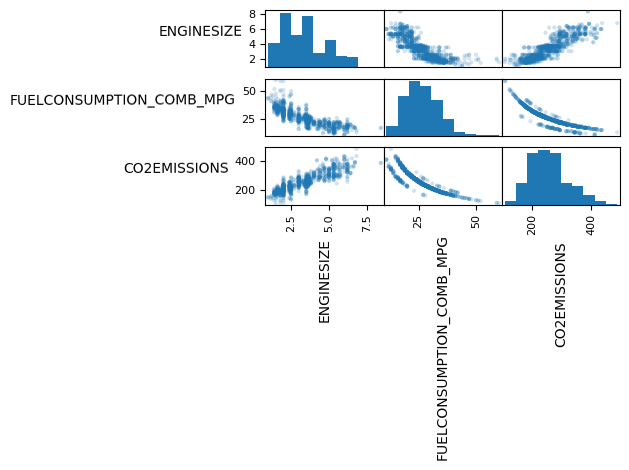

In [20]:
axes = pd.plotting.scatter_matrix(df, alpha=0.2)

for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0.2)
    ax.yaxis.label.set_ha('right')

plt.tight_layout()
plt.gcf().subplots_adjust(wspace=0,hspace=0.2)
plt.show()

# 🔍 Part 11: Architectural Insights on Feature Non-Linearity

Based on our scatter matrix analysis, the visual interaction between `'FUELCONSUMPTION_COMB_MPG'` and `'CO2EMISSIONS'` yields two profound data science observations:

1. **Non-Linear Behavior**: The relationship is distinctly curved rather than strictly straight. Ordinary Linear Regression assumes straight-line vectors, meaning a standard linear plane will not capture this curve perfectly. We will learn how to handle this structural curvature in the upcoming **Polynomial Regression** lab.
2. **The Tri-Curve Phenomenon**: The presence of **three clearly separated parallel curves** strongly implies that hidden categorical variables (such as `FUELTYPE`—Diesel, Regular Gasoline, or Premium Gasoline) are segmenting the cars into different operational profiles.

---

## 🎯 Our Immediate Modeling Objective

While deep categorical engineering and non-linear polynomial transformations are deferred to later exercises, our goal right now is purely baseline testing:
* We want to model the data **as-is** using Multiple Linear Regression.
* This will help us determine if adding the raw fuel economy metrics can account for a higher percentage of variance in our target variable (`CO2EMISSIONS`) compared to our previous single-variable models.

# 📥 Part 12: Feature Extraction using Index-Based Location (`.iloc`)

Before partitioning our dataset for training, we must isolate our matrix of independent variables ($X$) from our target column vector ($y$). We achieve this cleanly using index-based positioning.

---

## 🛠️ Code Implementation

We use the Pandas `.iloc` operator. By specifying integer positions rather than text strings, we decouple our code from any future column renaming modifications. We immediately append `.to_numpy()` to transform the sliced data structures into efficient NumPy multidimensional arrays.

```python
# Extract independent features (ENGINESIZE, FUELCONSUMPTION_COMB_MPG) using integer indices
X = df.iloc[:, [0, 1]].to_numpy()

# Extract dependent target label (CO2EMISSIONS) using integer index
y = df.iloc[:, [2]].to_numpy()

# Verify structural dimensions of the sliced numerical containers
print("X array shape:", X.shape)
print("y array shape:", y.shape)

In [22]:
# Extract the independent input features into a 2D NumPy array using uppercase X
X = df.iloc[:, [0, 1]].to_numpy()

# Extract the dependent target label into a 2D NumPy array using lowercase y
y = df.iloc[:, [2]].to_numpy()

# Print the dimensions to verify the array structures
print("X array shape:", X.shape)
print("y array shape:", y.shape)

X array shape: (1067, 2)
y array shape: (1067, 1)


# ⚖️ Part 13: Feature Preprocessing — Feature Standardization

Before passing our independent matrices into the regression framework, we must scale our features. `ENGINESIZE` (ranging between 1 to 7) and `FUELCONSUMPTION_COMB_MPG` (ranging between 10 to 60) have vastly different magnitudes. 

If left unscaled, the gradient descent or ordinary least squares algorithm might inadvertently favor the variable with the larger absolute value, skewing the model's coefficient weights.

---

## 🛠️ Code Implementation

We utilize `StandardScaler` from `scikit-learn` to apply Z-score normalization. This mathematical transform subtracts the column mean ($\mu$) from each data point and divides it by the standard deviation ($\sigma$):

$$X_{std} = \frac{X - \mu}{\sigma}$$

This forces both features to share a common center where the $\text{mean} = 0$ and $\text{standard deviation} = 1$.

```python
from sklearn import preprocessing

# Instantiate the scaler setup
std_scaler = preprocessing.StandardScaler()

# Fit parameters and transform the feature matrix
X_std = std_scaler.fit_transform(X)

# Inspect the structured scaling result
print("First 5 rows of scaled data:\n", X_std[:5])

In [24]:
from sklearn import preprocessing

# 1. Initialize the StandardScaler object
std_scaler = preprocessing.StandardScaler()

# 2. Compute the mean/std and transform the raw features (X) into standardized features (X_std)
X_std = std_scaler.fit_transform(X)

# 3. Preview the first 5 rows of transformed data to verify the scale change
print("First 5 rows of scaled data:\n", X_std[:5])

First 5 rows of scaled data:
 [[-0.9512918   0.87855306]
 [-0.66865251  0.34273362]
 [-1.30459092  2.88787597]
 [ 0.10860554 -0.19308583]
 [ 0.10860554  0.0748239 ]]


# 📊 Part 14: Verification of Standardized Distributions & Data Leakage Warnings

We convert our standardized NumPy array back into a temporary Pandas DataFrame to audit the numerical metrics using `.describe().round(2)`. 

---

## 🛠️ Code Implementation

This diagnostic step verifies that our mathematical scaling function operated perfectly across both feature dimensions.

```python
import pandas as pd

# Check statistics of the scaled array and round to 2 decimal places
pd.DataFrame(X_std).describe().round(2)

In [27]:
# Convert the standardized NumPy array back to a DataFrame to view statistics
# Use .round(2) to cleanly display values to two decimal places
standardized_summary = pd.DataFrame(X_std).describe().round(2)

# Display the statistical summary table
standardized_summary

,0,1
count,1067.00,1067.00
mean,0.00,-0.00
std,1.00,1.00
min,-1.66,-2.07
25%,-0.95,-0.73
50%,0.04,-0.06
75%,0.67,0.61
max,3.57,4.50


from sklearn.model_selection import train_test_split

# Split the standardized features and target into 80% train and 20% test sets
# random_state=42 guarantees consistent splitting across all runs
X_train, X_test, y_train, y_test = train_test_split(X_std, y, test_size=0.2, random_state=42)

# Verify the dimensional breakdown of the split subsets
print(f"Training features shape (80%): {X_train.shape}")
print(f"Testing features shape (20%): {X_test.shape}")
print(f"Training target shape (80%): {y_train.shape}")
print(f"Testing target shape (20%): {y_test.shape}")

In [28]:
from sklearn.model_selection import train_test_split

# Split the standardized features and target into 80% train and 20% test sets
# random_state=42 guarantees consistent splitting across all runs
X_train, X_test, y_train, y_test = train_test_split(X_std, y, test_size=0.2, random_state=42)

# Verify the dimensional breakdown of the split subsets
print(f"Training features shape (80%): {X_train.shape}")
print(f"Testing features shape (20%): {X_test.shape}")
print(f"Training target shape (80%): {y_train.shape}")
print(f"Testing target shape (20%): {y_test.shape}")

Training features shape (80%): (853, 2)
Testing features shape (20%): (214, 2)
Training target shape (80%): (853, 1)
Testing target shape (20%): (214, 1)


# 🤖 Part 16: Model Initialization & Multiple Linear Regression Training

We are now ready to construct our multi-variable hyperplane equation. In `scikit-learn`, the implementation mechanics of Simple Linear Regression and Multiple Linear Regression are identical; the framework automatically detects the dimensions based on the shape of the training matrix input ($X$).

---

## 🛠️ Code Implementation

We initialize the `LinearRegression()` object and invoke the `.fit()` method using our scaled training pairs. The optimization engine runs the Ordinary Least Squares (OLS) algorithm to minimize the residual sum of squares.

```python
from sklearn import linear_model

# Initialize the regression engine
regressor = linear_model.LinearRegression()

# Train the model using standardized training partitions
regressor.fit(X_train, y_train)

# Extract optimized regression attributes
coef_ = regressor.coef_
intercept_ = regressor.intercept_

print('Coefficients (Slopes): ', coef_)
print('Intercept (Constant):  ', intercept_)

In [32]:
from sklearn import linear_model

# 1. Instantiate the Multiple Linear Regression model object
regressor = linear_model.LinearRegression()

# 2. Train the model using the standardized training features and labels
regressor.fit(X_train, y_train)

# 3. Extract the calculated multi-dimensional hyperplane parameters
coef_ = regressor.coef_
intercept_ = regressor.intercept_

# 4. Display the results clearly
print('Coefficients (Slopes): ', coef_)
print('Intercept (Constant):  ', intercept_)


Coefficients (Slopes):  [[ 25.27339614 -37.4381472 ]]
Intercept (Constant):   [256.29072488]


# 🔄 Part 17: Parameter Transformation Back to Original Feature Space

The calculated parameters ($\text{Slopes} \approx [25.27, -37.43]$ and $\text{Intercept} \approx 256.29$) define a mathematical hyperplane optimized inside an abstract, standardized Z-score space. To make these insights actionable for real-world engineers, we must map these vectors back to their native physical units (Liters and Miles Per Gallon).

---

## 🧮 Mathematical Back-Transformation Mechanics

Using standard algebraic substitution, we untangle the Z-score equation ($X_{std} = \frac{X_{orig} - \mu}{\sigma}$) from the trained regression model. The formulas to map the parameters back to the unstandardized dimensions are defined as:

### 1. Unstandardized Slopes ($\theta_i$)
$$\theta_i = \frac{\beta_i}{\sigma_i}$$

### 2. Unstandardized Intercept ($\theta_0$)
$$\theta_0 = \beta_0 - \sum_{i=1}^{n} \frac{\beta_i \mu_i}{\sigma_i}$$

Where:
* $\beta_i, \beta_0$: Standardized coefficients and intercept generated by `regressor.fit()`.
* $\mu_i, \sigma_i$: Empirical means and standard deviations computed during the original `std_scaler.fit_transform()` phase.

---

## 🛠️ Code Implementation

We extract the baseline metrics from our `StandardScaler` instances and run the vector algebra arrays.

```python
import numpy as np

# Extract statistical properties from the fitted preprocessing scaler instance
means = std_scaler.mean_
std_devs = np.sqrt(std_scaler.var_)

# Apply scaling transformation to recover original slopes
original_coef = regressor.coef_[0] / std_devs

# Apply offset transformation to recover the original intercept constant
original_intercept = regressor.intercept_[0] - np.sum((regressor.coef_[0] * means) / std_devs)

# Print the real-world physical parameters
print("--- Real-World Unstandardized Parameters ---")
print("Original Space Coefficients (Slopes): ", original_coef)
print("Original Space Intercept (Constant):  ", original_intercept)

In [33]:
import numpy as np

# 1. Extract the means (mu) and standard deviations (sigma) from our trained scaler
means = std_scaler.mean_
std_devs = np.sqrt(std_scaler.var_)

# 2. Transform the coefficients back to the original unstandardized feature space
original_coef = regressor.coef_[0] / std_devs

# 3. Transform the intercept back to the original unstandardized feature space
original_intercept = regressor.intercept_[0] - np.sum((regressor.coef_[0] * means) / std_devs)

# 4. Display the real-world unstandardized parameters
print("--- Real-World Unstandardized Parameters ---")
print("Original Space Coefficients (Slopes): ", original_coef)
print("Original Space Intercept (Constant):  ", original_intercept)
print("\n--- Real-World Predictive Equation ---")
print(f"CO2 = {original_intercept:.2f} + ({original_coef[0]:.2f} * ENGINESIZE) + ({original_coef[1]:.2f} * FUELCONSUMPTION_COMB_MPG)")


--- Real-World Unstandardized Parameters ---
Original Space Coefficients (Slopes):  [17.8581369  -5.01502179]
Original Space Intercept (Constant):   329.13639670253883

--- Real-World Predictive Equation ---
CO2 = 329.14 + (17.86 * ENGINESIZE) + (-5.02 * FUELCONSUMPTION_COMB_MPG)


# 🧠 Part 18: Critical Evaluation — The Intercept Contradiction & Model Limitations

Mathematically, our recovered baseline equation yields an unstandardized **Intercept of $\approx 329\text{ g/km}$**. This presents a fascinating logical inconsistency when evaluated against real-world physics:

$$\text{If } \text{ENGINESIZE} = 0 \text{ and } \text{MPG} = 0, \text{ then } \text{CO2EMISSIONS} \text{ should ideally be } 0\text{ g/km}.$$

However, our structural hyperplane predicts that a non-existent vehicle with zero fuel dependency would still emit a massive mass of carbon per kilometer.

---

## 🔍 Why does this logical discrepancy occur?

1. **The Linear Enforcement Bias**: As explicitly proven by our diagnostic scatter matrix, the true relationship between fuel economy and emissions is fundamentally **non-linear (curved)**. Forcing an ordinary linear hyperplane over curved distribution clusters creates a geometric offset, causing the intercept plane to anchor way too high.
2. **The Danger of Extrapolation**: Machine learning models optimize strictly within the boundaries of their empirical training domain. Our dataset contains active vehicles (e.g., engine sizes from $1.5L$ to $6.8L$). It has zero reference instances for a $0L$ engine. Forcing the model to guess at $(0,0)$ forces catastrophic extrapolation error.
3. **Influence of Outliers**: Extreme performance variants or experimental vehicle configurations act as statistical outliers, pulling and tilting the ordinary least squares (OLS) regression plane away from a true logical origin.

---

## 🛠️ Advanced Pipeline Solutions
To resolve these architectural flaws later in the specialization, we will deploy:
* **Polynomial Regression**: To warp our flat linear space into a flexible curve that conforms cleanly to the actual data coordinates.
* **Regularization Techniques (Ridge / Lasso / ElasticNet)**: To apply penalty constraints onto the feature weights ($\theta$), stabilizing structural bias.
* **Outlier Mitigation**: Utilizing robust scalers or isolation forests during preprocessing to clip leverage points.

# 🗺️ Part 19: 3D Visualization of the Fitted Regression Hyperplane

Since our Multiple Linear Regression model utilizes two independent variables ($X_1$: `ENGINESIZE`, $X_2$: `FUELCONSUMPTION_COMB_MPG`), the geometric solution is no longer a simple 2D line. Instead, it forms a **3D multi-dimensional plane (Hyperplane)**.

---

## 🛠️ Code Implementation

We use `matplotlib`'s `3d` projection engine. We construct a coordinate mesh grid using `np.meshgrid` to map out the predicted plane's topography, and separate our test data points based on whether they sit **above** or **below** the model's prediction canopy.

```python
# Slicing vectors and generating coordinate mesh grids for the plane
X1 = X_test[:, 0] if X_test.ndim > 1 else X_test
X2 = X_test[:, 1] if X_test.ndim > 1 else np.zeros_like(X1)

x1_surf, x2_surf = np.meshgrid(np.linspace(X1.min(), X1.max(), 100), 
                               np.linspace(X2.min(), X2.max(), 100))

# Map the regression math onto the grid surface
y_surf = intercept_[0] + coef_[0, 0] * x1_surf + coef_[0, 1] * x2_surf

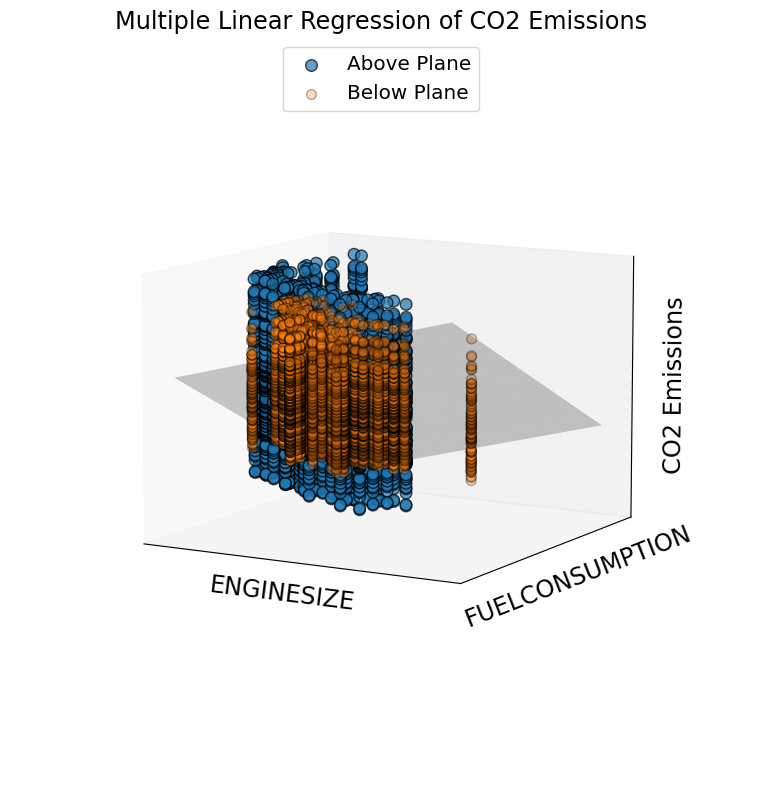

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Ensure X1, X2, and y_test have compatible shapes for 3D plotting
X1 = X_test[:, 0] if X_test.ndim > 1 else X_test
X2 = X_test[:, 1] if X_test.ndim > 1 else np.zeros_like(X1)

# 2. Create a mesh grid for plotting the regression plane
x1_surf, x2_surf = np.meshgrid(np.linspace(X1.min(), X1.max(), 100), 
                               np.linspace(X2.min(), X2.max(), 100))

# Calculate the continuous Z-axis values for the regression plane
y_surf = intercept_[0] + coef_[0, 0] * x1_surf + coef_[0, 1] * x2_surf

# 3. Predict y values using trained regression model to isolate residuals
y_pred = regressor.predict(X_test)
above_plane = (y_test >= y_pred).flatten()
below_plane = (y_test < y_pred).flatten()

# 4. Canvas Initialization for 3D Projection
fig = plt.figure(figsize=(20, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the data points above and below the plane in different contrast scales
ax.scatter(X1[above_plane], X2[above_plane], y_test[above_plane], label="Above Plane", s=70, alpha=0.7, ec='k')
ax.scatter(X1[below_plane], X2[below_plane], y_test[below_plane], label="Below Plane", s=50, alpha=0.3, ec='k')

# Plot the transparent 3D regression plane
ax.plot_surface(x1_surf, x2_surf, y_surf, color='k', alpha=0.21)

# 5. Set custom rotation view and descriptive labels
ax.view_init(elev=10)
ax.legend(fontsize='x-large', loc='upper center')
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.set_box_aspect(None, zoom=0.75)

ax.set_xlabel('ENGINESIZE', fontsize='xx-large')
ax.set_ylabel('FUELCONSUMPTION', fontsize='xx-large')
ax.set_zlabel('CO2 Emissions', fontsize='xx-large')
ax.set_title('Multiple Linear Regression of CO2 Emissions', fontsize='xx-large')

plt.tight_layout()
plt.show()

# 📉 Part 20: Visualizing Hyperplane Components via Vertical 2D Slices

While a 3D visualization is conceptually elegant, interpreting structural deviation can be visually challenging. To resolve this, we decouple our multi-variable model and examine **vertical 2D slices** of the hyperplane. We plot each independent variable separately against the target while utilizing its specific partial regression weight ($\theta$).

---

## 🛠️ Code Implementation

We use standard `matplotlib` configurations to output two separate dimensional analysis charts:
1. **Engine Size Axis**: Captures the positive gradient constraint ($\theta_1 \approx 25.27$).
2. **Fuel Economy Axis**: Captures the negative gradient constraint ($\theta_2 \approx -37.43$).

```python
import matplotlib.pyplot as plt

# Generate the 2D dimensional slice for Engine Size
plt.figure(figsize=(10, 4))
plt.scatter(X_train[:, 0], y_train, color='blue', alpha=0.5)
plt.plot(X_train[:, 0], coef_[0, 0] * X_train[:, 0] + intercept_[0], '-r')
plt.xlabel("Engine Size (Standardized)")
plt.ylabel("Emission")
plt.show()

# Generate the 2D dimensional slice for Fuel Economy (MPG)
plt.figure(figsize=(10, 4))
plt.scatter(X_train[:, 1], y_train, color='blue', alpha=0.5)
plt.plot(X_train[:, 1], coef_[0, 1] * X_train[:, 1] + intercept_[0], '-r')
plt.xlabel("FUELCONSUMPTION_COMB_MPG (Standardized)")
plt.ylabel("Emission")
plt.show()

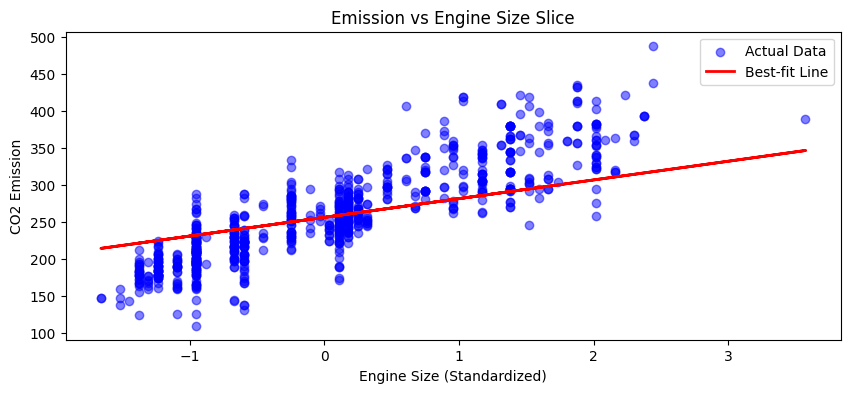

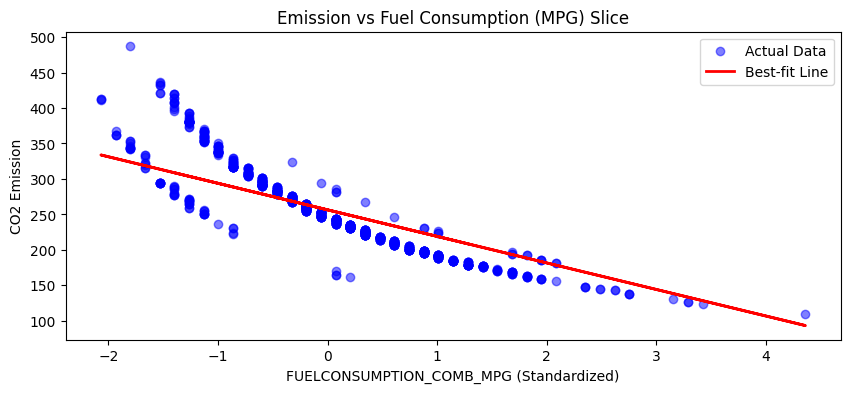

In [35]:
import matplotlib.pyplot as plt

# --- Plot 1: Vertical Slice for ENGINESIZE ---
plt.figure(figsize=(10, 4))
plt.scatter(X_train[:, 0], y_train, color='blue', alpha=0.5, label='Actual Data')
plt.plot(X_train[:, 0], coef_[0, 0] * X_train[:, 0] + intercept_[0], '-r', linewidth=2, label='Best-fit Line')
plt.xlabel("Engine Size (Standardized)")
plt.ylabel("CO2 Emission")
plt.title("Emission vs Engine Size Slice")
plt.legend()
plt.show()

# --- Plot 2: Vertical Slice for FUELCONSUMPTION_COMB_MPG ---
plt.figure(figsize=(10, 4))
plt.scatter(X_train[:, 1], y_train, color='blue', alpha=0.5, label='Actual Data')
plt.plot(X_train[:, 1], coef_[0, 1] * X_train[:, 1] + intercept_[0], '-r', linewidth=2, label='Best-fit Line')
plt.xlabel("FUELCONSUMPTION_COMB_MPG (Standardized)")
plt.ylabel("CO2 Emission")
plt.title("Emission vs Fuel Consumption (MPG) Slice")
plt.legend()
plt.show()

# ✍️ Exercise 1: Isolating Single-Variable Baseline (`ENGINESIZE` Only)

To compare our multi-variable model performance against a standard baseline, we isolate a single input vector. We extract only the standardized engine displacement capacity data to train a standalone Simple Linear Regression model.

---

## 🛠️ Code Implementation

We use NumPy slicing notation `[:, [0]]` to safely pull the first column matrix from `X_train` without flat-collapsing its dimensions. Then, we call the standard `.fit()` sequence.

```python
from sklearn import linear_model

# Slice the first column vector representing standardized Engine Size
X_train_1 = X_train[:, [0]]

# Instantiate the single-variable regressor
regressor_1 = linear_model.LinearRegression()

# Execute model optimization routines
regressor_1.fit(X_train_1, y_train)

# Retrieve single weight slope and baseline scalar intercept
coef_1 = regressor_1.coef_
intercept_1 = regressor_1.intercept_

print('Coefficients: ', coef_1)
print('Intercept:    ', intercept_1)

In [37]:
from sklearn import linear_model

# 1. Extract only the first column (index 0 - ENGINESIZE) from our standardized training data
# We use [[0]] or reshape to ensure it stays as a 2D matrix structure
X_train_1 = X_train[:, [0]]

# Initialize the new Simple Linear Regression model object
regressor_1 = linear_model.LinearRegression()

# 2. Train the model using only the engine size data
regressor_1.fit(X_train_1, y_train)

# 3. Extract the calculated coefficient and intercept parameters
coef_1 = regressor_1.coef_
intercept_1 = regressor_1.intercept_

# 4. Display the results clearly
print('Coefficients: ', coef_1)
print('Intercept:    ', intercept_1)

Coefficients:  [[55.18408797]]
Intercept:     [256.77183014]


# 📉 Exercise 2: Visualizing Single-Variable Best-Fit Regression Line

Now that we have successfully calculated the parameters ($\theta_1, \theta_0$) for our single-variable baseline model, we visualize its accuracy by plotting the red predictive regression line directly over our actual training data distribution coordinates.

---

## 🛠️ Code Implementation

We use `plt.scatter` to plot the empirical training data pairs and `plt.plot` to draw the optimized response vector mapping across the standardized feature axis.

```python
import matplotlib.pyplot as plt

# Plot actual distribution scatter matrix points
plt.scatter(X_train_1, y_train, color='blue', alpha=0.5, label='Training Data')

# Plot the single-variable regression boundary vector
plt.plot(X_train_1, coef_1[0] * X_train_1 + intercept_1, '-r', linewidth=2, label='Best-fit Line')

# Set aesthetic context options
plt.xlabel("Engine size (Standardized)")
plt.ylabel("Emission")
plt.title("Simple Linear Regression: Emission vs Engine Size")
plt.legend()
plt.show()

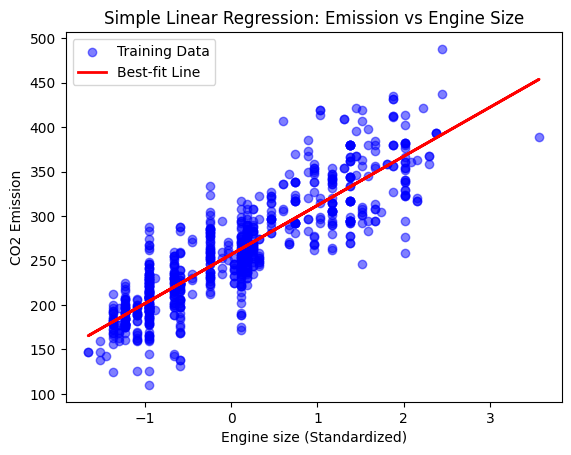

In [38]:
import matplotlib.pyplot as plt

# 1. Plot the actual training data points as blue dots
plt.scatter(X_train_1, y_train, color='blue', alpha=0.5, label='Training Data')

# 2. Plot the best-fit simple regression line as a red line (-r)
plt.plot(X_train_1, coef_1[0] * X_train_1 + intercept_1, '-r', linewidth=2, label='Best-fit Line')

# 3. Add descriptive labels and legend
plt.xlabel("Engine size (Standardized)")
plt.ylabel("CO2 Emission")
plt.title("Simple Linear Regression: Emission vs Engine Size")
plt.legend()

# 4. Display the graph cleanly
plt.show()

# 📉 Exercise 3: Evaluating Single-Variable Model on Testing Partition

To test the generalization capability of our trained baseline framework, we evaluate the predictive boundary using the unseen testing subset ($X_{\text{test}}, y_{\text{test}}$). This guarantees that our algorithm has captured structural trends rather than simply memorizing training instances.

---

## 🛠️ Code Implementation

We isolate the standardized engine displacement configurations from the test array using `[:, [0]]` and draw our previously calculated linear vector parameters across the test distribution canopy.

```python
import matplotlib.pyplot as plt

# Slice the standardized Engine Size vector from the unseen test partition
X_test_1 = X_test[:, [0]]

# Plot the empirical test coordinates
plt.scatter(X_test_1, y_test, color='blue', alpha=0.5, label='Test Data')

# Project the trained regression boundary across the test grid space
plt.plot(X_test_1, coef_1[0] * X_test_1 + intercept_1, '-r', linewidth=2, label='Best-fit Line')

# Set graph canvas options
plt.xlabel("Engine size (Standardized)")
plt.ylabel("CO2 Emission")
plt.title("Simple Linear Regression: Evaluation on Test Data")
plt.legend()
plt.show()

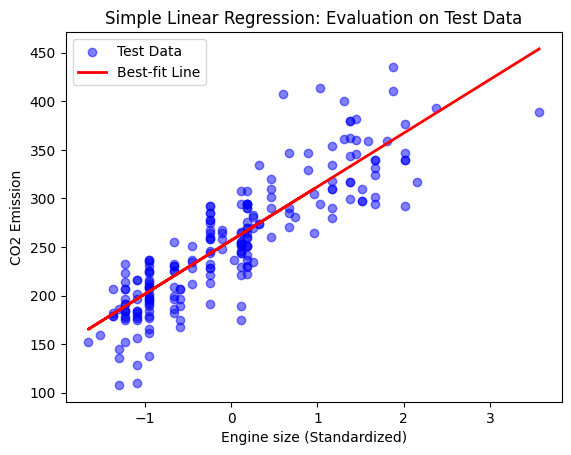

In [39]:
import matplotlib.pyplot as plt

# 1. Slice the first column (index 0 - ENGINESIZE) from our standardized test data
X_test_1 = X_test[:, [0]]

# 2. Plot the actual testing data points as blue dots
plt.scatter(X_test_1, y_test, color='blue', alpha=0.5, label='Test Data')

# 3. Plot the best-fit regression line using the test feature slice
plt.plot(X_test_1, coef_1[0] * X_test_1 + intercept_1, '-r', linewidth=2, label='Best-fit Line')

# 4. Add descriptive labels and titles
plt.xlabel("Engine size (Standardized)")
plt.ylabel("CO2 Emission")
plt.title("Simple Linear Regression: Evaluation on Test Data")
plt.legend()

# 5. Display the graph cleanly
plt.show()

# ✍️ Exercise 4: Isolating Single-Variable Baseline (`FUELCONSUMPTION_COMB_MPG` Only)

To evaluate the standalone predictive strength of our fuel economy feature, we construct a separate single-variable baseline model. We isolate the standardized aggregate miles-per-gallon vector and compute its distinct linear parameters.

---

## 🛠️ Code Implementation

We use NumPy indexing `[:, [1]]` to pull the second column matrix from our standardized `X_train` matrix. Then, we fit the ordinary least squares algorithm to isolate the specific slope ($\theta$) and intercept ($\theta_0$).

```python
from sklearn import linear_model

# Slice the second column vector representing standardized Fuel Consumption (MPG)
X_train_2 = X_train[:, [1]]

# Instantiate the single-variable regressor setup
regressor_2 = linear_model.LinearRegression()

# Train the model on the isolated fuel metrics subset
regressor_2.fit(X_train_2, y_train)

# Retrieve standalone slope weight and intercept constant
coef_2 = regressor_2.coef_
intercept_2 = regressor_2.intercept_

print('Coefficients (Slope): ', coef_2)
print('Intercept (Constant): ', intercept_2)

In [40]:
from sklearn import linear_model

# 1. Extract only the second column (index 1 - FUELCONSUMPTION_COMB_MPG) from our standardized training data
X_train_2 = X_train[:, [1]]

# Initialize the new Simple Linear Regression model object
regressor_2 = linear_model.LinearRegression()

# 2. Train the model using only the fuel consumption data
regressor_2.fit(X_train_2, y_train)

# 3. Extract the calculated coefficient and intercept parameters
coef_2 = regressor_2.coef_
intercept_2 = regressor_2.intercept_

# 4. Display the parameters clearly
print('Coefficients (Slope): ', coef_2)
print('Intercept (Constant): ', intercept_2)

Coefficients (Slope):  [[-58.51827989]]
Intercept (Constant):  [256.09392179]


# 📉 Exercise 5: Evaluating Fuel Economy Baseline on Testing Partition

To complete our baseline evaluation, we project our isolated fuel economy regression vector ($\theta_{\text{MPG}}$) against the unseen testing partition ($X_{\text{test}}, y_{\text{test}}$). This allows us to visually diagnose the limitations of applying strict linear constraints onto non-linear distributions.

---

## 🛠️ Code Implementation

We extract the standardized MPG index using NumPy notation `[:, [1]]` and map the corresponding slope and intercept configurations over the testing grid.

```python
import matplotlib.pyplot as plt

# Slice the standardized Fuel Consumption (MPG) column from the test array
X_test_2 = X_test[:, [1]]

# Plot the actual test distribution coordinates
plt.scatter(X_test_2, y_test, color='blue', alpha=0.5, label='Test Data')

# Project the trained linear boundary across the test grid space
plt.plot(X_test_2, coef_2[0] * X_test_2 + intercept_2, '-r', linewidth=2, label='Best-fit Line')

# Set canvas properties
plt.xlabel("FUELCONSUMPTION_COMB_MPG (Standardized)")
plt.ylabel("CO2 Emission")
plt.title("Simple Linear Regression: Fuel Economy vs Emission on Test Data")
plt.legend()
plt.show()

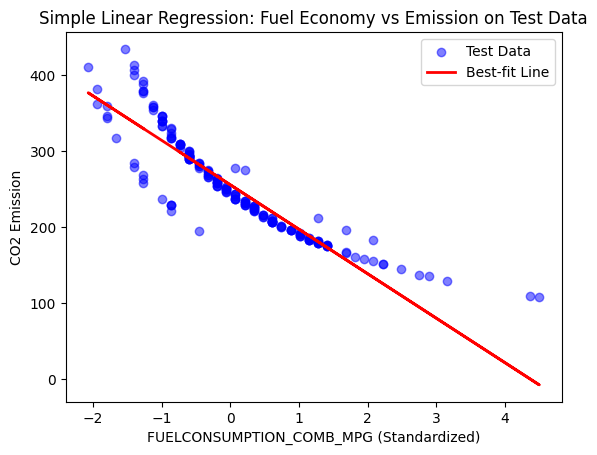

In [41]:
import matplotlib.pyplot as plt

# 1. Slice the second column (index 1 - FUELCONSUMPTION_COMB_MPG) from our standardized test data
X_test_2 = X_test[:, [1]]

# 2. Plot the actual testing data points as blue dots
plt.scatter(X_test_2, y_test, color='blue', alpha=0.5, label='Test Data')

# 3. Plot the best-fit regression line using the test feature slice
plt.plot(X_test_2, coef_2[0] * X_test_2 + intercept_2, '-r', linewidth=2, label='Best-fit Line')

# 4. Add descriptive labels and titles
plt.xlabel("FUELCONSUMPTION_COMB_MPG (Standardized)")
plt.ylabel("CO2 Emission")
plt.title("Simple Linear Regression: Fuel Economy vs Emission on Test Data")
plt.legend()

# 5. Display the graph cleanly
plt.show()

# 🏁 Part 21: Final Model Evaluation & Performance Comparison

To scientifically determine which model configuration delivers the highest predictive accuracy on unseen data, we evaluate all three frameworks using **Mean Squared Error (MSE)** and the **$R^2$ Score** metrics derived from the testing partition.

---

## 🛠️ Code Implementation

We import statistical evaluation functions from `sklearn.metrics` and aggregate the mathematical scores into a structured summary table for objective benchmarking.

```python
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Predict outputs using test data vectors across all trained algorithms
y_pred_multi = regressor.predict(X_test)
y_pred_simple1 = regressor_1.predict(X_test[:, [0]])
y_pred_simple2 = regressor_2.predict(X_test[:, [1]])

# Assemble benchmarking matrix properties
metrics_data = {
    'Model Configuration': [
        'Multiple Regression (Engine Size + MPG)', 
        'Simple Regression (Engine Size Only)', 
        'Simple Regression (Fuel Economy MPG Only)'
    ],
    'Mean Squared Error (MSE)': [
        mean_squared_error(y_test, y_pred_multi),
        mean_squared_error(y_test, y_pred_simple1),
        mean_squared_error(y_test, y_pred_simple2)
    ],
    'R2 Score (Variance Explained)': [
        r2_score(y_test, y_pred_multi),
        r2_score(y_test, y_pred_simple1),
        r2_score(y_test, y_pred_simple2)
    ]
}

# Render comparative dataframe matrix
evaluation_df = pd.DataFrame(metrics_data)
evaluation_df.round(4)

In [42]:
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# 1. Generate predictions for all three models using the unseen test partitions
y_pred_multi = regressor.predict(X_test)
y_pred_simple1 = regressor_1.predict(X_test[:, [0]])
y_pred_simple2 = regressor_2.predict(X_test[:, [1]])

# 2. Construct a comprehensive summary table to compare performance metrics
metrics_data = {
    'Model Configuration': [
        'Multiple Regression (Engine Size + MPG)', 
        'Simple Regression (Engine Size Only)', 
        'Simple Regression (Fuel Economy MPG Only)'
    ],
    'Mean Squared Error (MSE)': [
        mean_squared_error(y_test, y_pred_multi),
        mean_squared_error(y_test, y_pred_simple1),
        mean_squared_error(y_test, y_pred_simple2)
    ],
    'R2 Score (Variance Explained)': [
        r2_score(y_test, y_pred_multi),
        r2_score(y_test, y_pred_simple1),
        r2_score(y_test, y_pred_simple2)
    ]
}

# Convert the metrics dictionary into a beautifully formatted Pandas DataFrame
evaluation_df = pd.DataFrame(metrics_data)
evaluation_df.round(4)

,Model Configuration,Mean Squared Error (MSE),R2 Score (Variance Explained)
0,Multiple Regression (Engine Size + MPG),466.1131,0.8873
1,Simple Regression (Engine Size Only),985.9382,0.7616
2,Simple Regression (Fuel Economy MPG Only),776.2149,0.8123
